In [1]:
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.sparse as sparse
from scipy.sparse import linalg as spla
from scipy import interpolate as interp

Populating the interactive namespace from numpy and matplotlib


# Multigrid model problem
$$ u'' = f(x), \quad u(0) = 1, \quad u(1) = 3.$$
$$f(x) = -20 + \frac{1}{2}\phi''(x)\cos(\phi(x)) - \frac{1}{2}(\phi'(x))^2\sin(\phi(x))$$
$$\phi(x) = 20\pi x^3 $$

## Solution
$$ u(x) = 1 + 12x - 10x^2 + \frac{1}{2}\sin(\phi(x)) $$

# Underelaxed Jacobi
$$ U_{k+1} = \left[I + w\frac{h^2}{2}A\right] U_k - w\frac{h^2}{2} F$$

In [2]:
def F(x):
    phi = 20*pi*x**3
    dphi = 20*pi*3*x**2
    ddphi = 20*pi*6*x
    return -20 + 0.5*ddphi*cos(phi) - 0.5*dphi**2*sin(phi)

def exact_soln(x):
    phi = 20*pi*x**3
    return 1 + 12*x - 10*x**2 + 0.5*sin(phi)

class Finite_Difference_Order2:
    def __init__(self, m, h):
        ## this method gets called once when you create an
        ## object
        self.m = int(m)
        assert self.m >= 0
        self.shape = (self.m, self.m)
        assert h > 0
        self.h = h
        self._factor = 1.

    ## a decorator modifies the behavior of a function or method
    ## in this case `classmethod` give the method the ability to
    ## instantiate a new version of the class with the input variable
    ## `cls` instead of `self`, which is an object
    @classmethod
    def _new(cls, matrix):
        """creates a new copy of the object"""
        new_matrix = cls(matrix.m, matrix.h)
        return new_matrix

    def __mul__(self, a):
        """Defines scalar multiplication self*a"""
        assert isscalar(a)
        result = self._new(self)
        result._factor *= a
        return result

    def __rmul__(self, a):
        """Defines scalar multiplication a*self"""
        return self.__mul__(a)

    def __matmul__(self, b):
        """Defines matrix vector multiplication self@b"""
        if b.ndim == 1:
            assert b.size == self.m
            result = b.copy()
            result[0] = -2*b[0] + b[1]
            for j in np.arange(1, self.m-1):
                result[j] = b[j-1] - 2*b[j] + b[j+1]
            result[-1] = -2*b[-1] + b[-2]
        result *= self._factor/self.h**2
        return result

    def __getitem__(self, key):
        """defines indexing for the object i.e., `object[index]`"""
        assert len(key) == 2
        i, j = key
        assert 0 <= i < self.m
        assert 0 <= j < self.m
        # if (i == j):
        #     output = -2.
        # elif (i-j == 1 or i-j == -1):
        #     output = 1.
        # else:
        #     output = 0.
        # return output
        # return -2 if i == j elif 1 if i-j == -1 or i-j == 1 else 0.
        return -2.*(i == j) + 1.*((i-j == 1)|(i-j == -1))

    def transpose(self):
        """This matrix is symmetric"""
        return self

def Jacobi(rhs, u0, m, nu, w=1.):
    assert rhs.size == u0.size
    h = 1/(m + 1)
    u = u0.copy()
    A = Finite_Difference_Order2(m, h)
    for n in arange(nu):
        u += w*h**2/2*(A@u - rhs)
    r = rhs - A@u
    return u, r

In [3]:
nu = 50

m = 256
h = 1/(m + 1)

x = linspace(0, 1, m + 2)
_x_ = x[1:-1]

f = F(x)
_f_ = f[1:-1]
_f_[0] -= 1/h**2
_f_[-1] -= 3/h**2

uexact = exact_soln(x)

u = uexact.copy()
_u_ = u[1:-1]

u0 = linspace(1, 3, m+2)
_u0_ = u0[1:-1]

@interact(nu=(0, 10000, 50))
def plot_fn(nu=0):
    _u_[:], _ = Jacobi(_f_, _u0_, m, nu)

    plot(x, u0)
    plot(x, u)
    plot(x, uexact, 'k')

interactive(children=(IntSlider(value=0, description='nu', max=10000, step=50), Output()), _dom_classes=('widg…

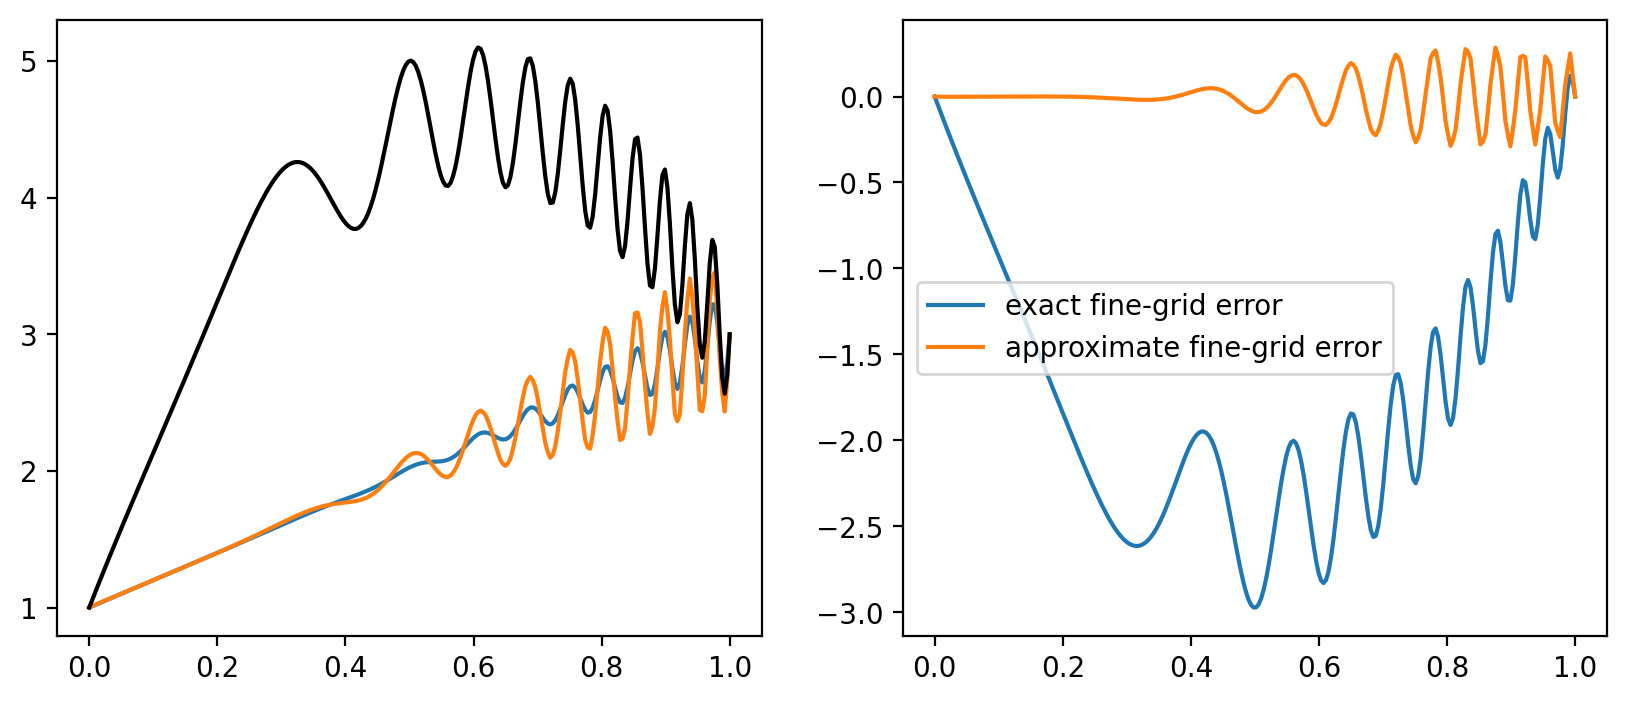

In [5]:
# 2 grid version

nu = 3

m = 256
h = 1/(m + 1)

x = linspace(0, 1, m + 2)

f = F(x)
f[1] -= 1/h**2
f[-2] -= 3/h**2

uexact = exact_soln(x)

u = uexact.copy()

u0 = linspace(1, 3, m+2)

r = zeros(m + 2)
u[1:-1], r[1:-1] = Jacobi(f[1:-1], u0[1:-1], m, nu)


# Ae = -r on the coarse grid

x_coarse = linspace(0, 1, m//2 + 2)

r_interp = interp.interp1d(x, r, 'linear')
r_coarse = r_interp(x_coarse)

e0_coarse = zeros(m//2 + 2)

e_coarse = zeros(m//2 + 2)

e_coarse[1:-1], _ = Jacobi(
    -r_coarse[1:-1], e0_coarse[1:-1], m//2, nu)

e_interp = interp.interp1d(x_coarse, e_coarse, 'linear')
e_fine = e_interp(x)


u_2g = u - e_fine

fig1 = figure(1, [10, 4])

fig1.add_subplot(121)
plot(x, u)
plot(x, u_2g)
plot(x, uexact, 'k')

fig1.add_subplot(122)
plot(x, u - uexact, label='exact fine-grid error')
plot(x, e_fine, label='approximate fine-grid error')
legend()